In [4]:
import pandas as pd
import numpy as np
import re
import tldextract

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
path = r"C:\Users\91738\OneDrive\Desktop\DESKTOP\PROJECTS\major project\dataset\malicious_phish.csv"

df = pd.read_csv(path)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (651191, 2)
                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement


In [6]:
df = df.dropna()
df = df.drop_duplicates()

print(df['type'].value_counts())

type
benign        428080
defacement     95308
phishing       94092
malware        23645
Name: count, dtype: int64


In [7]:
def extract_features(url):

    features = {}

    features['url_length'] = len(url)

    features['num_digits'] = sum(c.isdigit() for c in url)

    features['num_special_chars'] = len(re.findall(r'[!@#$%^&*(),.?":{}|<>]', url))

    features['num_hyphens'] = url.count('-')

    features['num_dots'] = url.count('.')

    features['num_slashes'] = url.count('/')

    features['num_question_marks'] = url.count('?')

    features['num_equals'] = url.count('=')

    features['https'] = 1 if "https" in url else 0

    ext = tldextract.extract(url)

    features['domain_length'] = len(ext.domain)

    features['subdomain_length'] = len(ext.subdomain)

    features['suffix_length'] = len(ext.suffix)

    return features

In [9]:
feature_list = df['url'].apply(extract_features)

features_df = pd.DataFrame(feature_list.tolist())

print(features_df.head())

   url_length  num_digits  num_special_chars  num_hyphens  num_dots  \
0          16           0                  2            1         2   
1          35           1                  2            0         2   
2          31           1                  2            0         2   
3          88           7                  8            1         3   
4         235          22                  6            1         2   

   num_slashes  num_question_marks  num_equals  https  domain_length  \
0            0                   0           0      0              9   
1            2                   0           0      0              7   
2            3                   0           0      0             10   
3            3                   1           4      0             14   
4            3                   1           3      0             19   

   subdomain_length  suffix_length  
0                 0              6  
1                 0              3  
2                 0          

In [10]:
le = LabelEncoder()

y = le.fit_transform(df['type'])

X = features_df

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
def feature_selection(X, y, n_features=8):

    corr = pd.DataFrame(X).corrwith(pd.Series(y))

    corr = abs(corr)

    selected = corr.sort_values(ascending=False).head(n_features).index

    return X[selected]

In [13]:
X_train = feature_selection(X_train, y_train, 8)

X_test = X_test[X_train.columns]

print("Selected Features:", X_train.columns)

Selected Features: Index(['https', 'num_special_chars', 'num_hyphens', 'domain_length',
       'num_dots', 'suffix_length', 'num_digits', 'num_slashes'],
      dtype='object')


In [16]:
import random
def cuckoo_search(X_train, y_train, iterations=15):

    best_score = 0
    best_params = None

    for i in range(iterations):

        n_estimators = random.randint(50,200)

        learning_rate = random.uniform(0.01,1)

        max_depth = random.randint(1,5)

        base = DecisionTreeClassifier(max_depth=max_depth)

        model = AdaBoostClassifier(
            estimator=base,
            n_estimators=n_estimators,
            learning_rate=learning_rate
        )

        model.fit(X_train,y_train)

        pred = model.predict(X_train)

        score = accuracy_score(y_train,pred)

        print(f"Iteration {i+1} Accuracy:",score)

        if score > best_score:
            best_score = score
            best_params = (n_estimators,learning_rate,max_depth)

    return best_params

In [17]:
best = cuckoo_search(X_train,y_train)

print("Best Parameters:",best)

Iteration 1 Accuracy: 0.8121836615324625
Iteration 2 Accuracy: 0.6659134334178203
Iteration 3 Accuracy: 0.8249054396568531
Iteration 4 Accuracy: 0.8556053811659193
Iteration 5 Accuracy: 0.8741119126535387
Iteration 6 Accuracy: 0.8676740105283681
Iteration 7 Accuracy: 0.8783875999220121
Iteration 8 Accuracy: 0.8726184441411581
Iteration 9 Accuracy: 0.7757652563852603
Iteration 10 Accuracy: 0.8654260089686099
Iteration 11 Accuracy: 0.8125073113667381
Iteration 12 Accuracy: 0.8440651199064145
Iteration 13 Accuracy: 0.8046558783388574
Iteration 14 Accuracy: 0.8756892181711835
Iteration 15 Accuracy: 0.7831780074088516
Best Parameters: (73, 0.9856493954916198, 5)


In [18]:
n_estimators, learning_rate, depth = best

base = DecisionTreeClassifier(max_depth=depth)

model = AdaBoostClassifier(
    estimator=base,
    n_estimators=n_estimators,
    learning_rate=learning_rate
)

model.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...r(max_depth=5)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",73
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.9856493954916198
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [19]:
y_pred = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:",accuracy)

print(classification_report(y_test,y_pred))

Accuracy: 0.8786898030805225
              precision    recall  f1-score   support

           0       0.91      0.95      0.93     85504
           1       0.85      0.92      0.88     19142
           2       0.95      0.78      0.86      4707
           3       0.73      0.55      0.62     18872

    accuracy                           0.88    128225
   macro avg       0.86      0.80      0.82    128225
weighted avg       0.87      0.88      0.87    128225



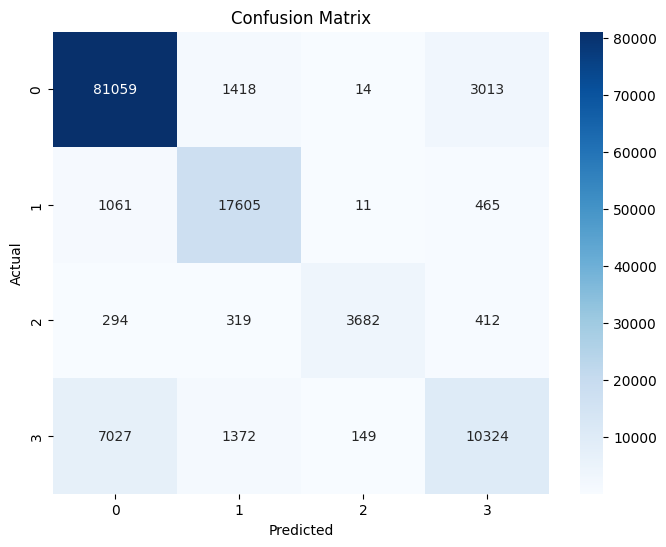

In [21]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt="d")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

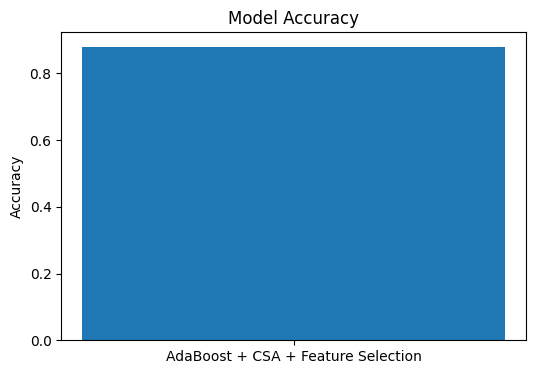

In [22]:
plt.figure(figsize=(6,4))

plt.bar(["AdaBoost + CSA + Feature Selection"],[accuracy])

plt.ylabel("Accuracy")

plt.title("Model Accuracy")

plt.show()

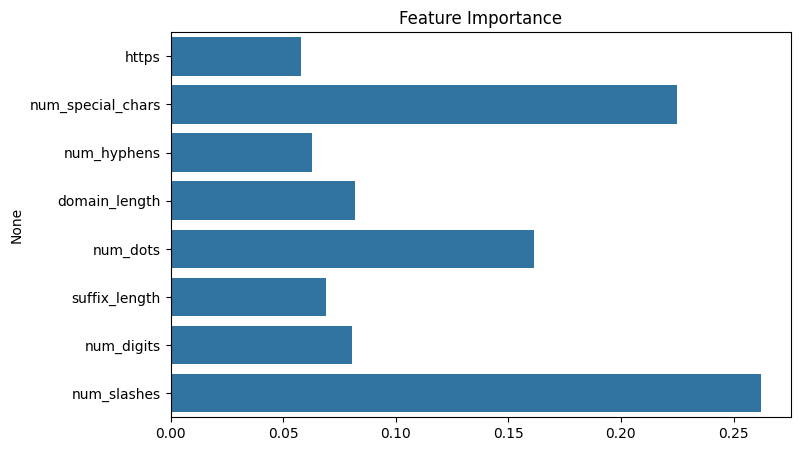

In [23]:
importances = model.feature_importances_

plt.figure(figsize=(8,5))

sns.barplot(x=importances,y=X_train.columns)

plt.title("Feature Importance")

plt.show()

In [39]:
test_url = "http://secure-paypal-login.verify-account.ru"

test_features = extract_features(test_url)

test_df = pd.DataFrame([test_features])

test_df = test_df[X_train.columns]

prediction = model.predict(test_df)

print("Predicted Class:",le.inverse_transform(prediction))

Predicted Class: ['phishing']
